# "Development of AI-assistant based of RAG-system". Baseline


### Data Preparation

In [ ]:
!pip install -q trafilatura beautifulsoup4 requests tqdm pandas numpy sentence_transformers faiss-cpu transformers accelerate datasets psycopg2-binary dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.6/132.6 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 130.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.9/837.9 kB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.7/318.7 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.7/274.7 kB 12.8 MB/s eta 0:00:00


In [ ]:
import random, os, re, math, json, time
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Параметры датасетов бейзлайна
TOP_K = 10
N_DOC_PAGES_PER_SOURCE = 100
CODESN_MAX_ROWS = 3000
CHUNK_SIZE = 900
CHUNK_OVERLAP = 150

# Векторная модель
EMB_MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"

# LLM для генерации
LLM_NAME = "google/flan-t5-base"

### Утилиты для скачивания и извлечения текста из HTML

In [ ]:
import requests
import re
from bs4 import BeautifulSoup

def fetch_html(url: str, timeout: int = 30) -> str | None:
    try:
        response = requests.get(url, timeout=timeout)
        response.raise_for_status()
        return response.text
    except Exception as e:
        print(f"[WARN] Failed to fetch {url}: {e}")
        return None


def html_to_text(html: str) -> str | None:
    if not html:
        return None

    soup = BeautifulSoup(html, "html.parser")

    # удаляем технические и навигационные элементы
    for tag in soup(["script", "style", "nav", "header", "footer"]):
        tag.decompose()

    text = soup.get_text(separator="\n")

    # чистка лишних переводов строк
    text = re.sub(r"\n{3,}", "\n\n", text).strip()

    if len(text) < 200:
        return None

    return text

### Документации Spark/Trino/Hive + сбор страниц

In [ ]:
from urllib.parse import urljoin, urlparse, urldefrag
from tqdm import tqdm
from pprint import pprint

random.seed(SEED)

def fetch_html(url: str, timeout: int = 20) -> str | None:
    try:
        r = requests.get(url, timeout=timeout)
        r.raise_for_status()
        return r.text
    except Exception:
        return None

def html_to_text_bs4(html: str) -> str | None:
    if not html:
        return None
    soup = BeautifulSoup(html, "html.parser")
    for tag in soup(["script", "style", "nav", "header", "footer"]):
        tag.decompose()
    text = soup.get_text("\n")
    text = re.sub(r"\n{3,}", "\n\n", text).strip()
    return text if len(text) > 400 else None

def extract_links(html: str, base_url: str) -> list[str]:
    soup = BeautifulSoup(html, "html.parser")
    links = []
    for a in soup.find_all("a", href=True):
        href = a["href"].strip()
        if href.startswith("mailto:") or href.startswith("javascript:"):
            continue
        full = urljoin(base_url, href)
        full, _frag = urldefrag(full)
        links.append(full)
    return links

def crawl_site(seed_url: str, allowed_prefixes: list[str], max_pages: int = 100, polite_sleep=(0.05, 0.15)):
    """
    BFS-краулер: стартуем с seed_url, идём по внутренним ссылкам,
    сохраняем страницы, которые начинаются с allowed_prefixes
    """
    seen = set()
    queue = [seed_url]
    pages = []

    def allowed(u: str) -> bool:
        return any(u.startswith(p) for p in allowed_prefixes)

    with tqdm(total=max_pages, desc=f"Crawling {seed_url}") as pbar:
        while queue and len(pages) < max_pages:
            url = queue.pop(0)
            if url in seen:
                continue
            seen.add(url)
            if not allowed(url):
                continue

            html = fetch_html(url)
            if not html:
                continue

            text = html_to_text_bs4(html)
            if text:
                pages.append({"url": url, "text": text})
                pbar.update(1)

            # вытягиваем новые ссылки
            for link in extract_links(html, url):
                if link not in seen and allowed(link):
                    queue.append(link)

            time.sleep(random.uniform(*polite_sleep))

    return pages

# Источники краулера
DOC_CRAWL_SOURCES = [
    {
        "source": "spark_docs",
        "seed": "https://spark.apache.org/docs/latest/",
        "allowed": [
            "https://spark.apache.org/docs/latest/"
        ],
        "max_pages": N_DOC_PAGES_PER_SOURCE,
    },
    {
        "source": "trino_docs",
        "seed": "https://trino.io/docs/current/",
        "allowed": [
            "https://trino.io/docs/current/"
        ],
        "max_pages": N_DOC_PAGES_PER_SOURCE,
    },
    {
        "source": "hive_docs",
        "seed": "https://cwiki.apache.org/confluence/display/Hive/",
        "allowed": [
            "https://cwiki.apache.org/confluence/display/Hive/"
        ],
        "max_pages": N_DOC_PAGES_PER_SOURCE,
    },
]

doc_rows = []
for src in DOC_CRAWL_SOURCES:
    pages = crawl_site(src["seed"], src["allowed"], max_pages=src["max_pages"])
    for p in pages:
        doc_rows.append({
            "source": src["source"],
            "url": p["url"],
            "title": p["url"].split("/")[-1] or p["url"],
            "text": p["text"],
        })

print("\nСкачано страниц документации:", len(doc_rows))
print("Пример: \n")
pprint(doc_rows[0])

Crawling https://trino.io/docs/current/: 100%|██████████| 100/100 [00:37<00:00,  2.65it/s]
Crawling https://cwiki.apache.org/confluence/display/Hive/: 100%|██████████| 100/100 [01:28<00:00,  1.13it/s]


Скачано страниц документации: 300
Пример: 

{'source': 'spark_docs',
 'text': 'Overview - Spark 4.1.1 Documentation\n'
         '\n'
         'Apache Spark - A Unified engine for large-scale data analytics\n'
         '\n'
         '                  Apache Spark is a unified analytics engine for '
         'large-scale data processing.\n'
         '                  It provides high-level APIs in Java, Scala, Python '
         'and R,\n'
         '                  and an optimized engine that supports general '
         'execution graphs.\n'
         '                  It also supports a rich set of higher-level tools '
         'including\n'
         '                  \n'
         'Spark SQL\n'
         ' for SQL and structured data processing,\n'
         '                  \n'
         'pandas API on Spark\n'
         ' for pandas workloads,\n'
         '                  \n'
         'MLlib\n'
         ' for machine learning,\n'
         '                  \n'
         'GraphX\

### CodeSearchNet subsample - подготовка датасета

> Оригинальный [CodeSearchNet](https://huggingface.co/datasets/code-search-net/code_search_net) недоступен для скачивания из HF, поэтому брал аналог [sentence-transformers/codesearchnet](https://huggingface.co/datasets/sentence-transformers/codesearchnet). Dataset содержит пары `comment` и `code` где расписаны соответственно пояснения (значения) кода и сам код. Пример:

```
{
  'comment': 'Computes the new parent id for the node being moved.\n\n@return int',
  'code': "protected function parentId()\n\t{\n\t\tswitch ( $this->position )\n\t\t{\n\t\t\tcase 'root':\n\t\t\t\treturn null;\n\n\t\t\tcase 'child':\n\t\t\t\treturn $this->target->getKey();\n\n\t\t\tdefault:\n\t\t\t\treturn $this->target->getParentId();\n\t\t}\n\t}",
}
```

> Еще одна особенность датасета - в ней нет четкого разделения между ЯП, поэтому датасет мультиязычен. Можно будет отдельным блоком научиться искать Python по характерному синтаксису и "выцепить" его в семпл, но для бейзлайна этого делать не будем

In [ ]:
from datasets import load_dataset
import pandas as pd

ds = load_dataset(
    "sentence-transformers/codesearchnet",
    split="train"
)

ds_small = ds.select(range(CODESN_MAX_ROWS))

def clean_text(s: str) -> str:
    s = (s or "").replace("\r", "\n")
    s = re.sub(r"\n{3,}", "\n\n", s)
    return s.strip()

code_rows = []
for i in tqdm(range(len(ds_small)), desc="Preparing CodeSearchNet rows"):
    r = ds_small[i]
    comment = clean_text(r.get("comment", ""))
    code = clean_text(r.get("code", ""))

    # фильтр пустоты
    if len(comment) < 20 or len(code) < 50:
        continue

    # Подготовка документа
    text = f"Comment:\n{comment}\n\nCode:\n{code}".strip()

    code_rows.append({
        "source": "codesearchnet",
        "url": "",
        "title": f"codesn_{i}",
        "comment": comment,
        "code": code,
        "text": text
    })

print("\nCodeSearchNet документов:", len(code_rows))
print("\nПример comment:\n", code_rows[0]["comment"])
print("\nПример code:\n", code_rows[0]["code"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

pair/train-00000-of-00003.parquet:   0%|          | 0.00/163M [00:00<?, ?B/s]

pair/train-00001-of-00003.parquet:   0%|          | 0.00/166M [00:00<?, ?B/s]

pair/train-00002-of-00003.parquet:   0%|          | 0.00/163M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1375067 [00:00<?, ? examples/s]

Preparing CodeSearchNet rows: 100%|██████████| 3000/3000 [00:00<00:00, 8183.97it/s]


CodeSearchNet документов: 2968

Пример comment:
 Computes the new parent id for the node being moved.

@return int

Пример code:
 protected function parentId()
	{
		switch ( $this->position )
		{
			case 'root':
				return null;

			case 'child':
				return $this->target->getKey();

			default:
				return $this->target->getParentId();
		}
	}


### Подготовка схем данных из Postgres DB

In [ ]:
import psycopg2
from psycopg2.extras import RealDictCursor
from dotenv import load_dotenv

load_dotenv()

NEON_DSN = os.environ.get("NEON_DSN")
assert NEON_DSN, "NEON_DSN не задан. Вставь строку подключения в os.environ['NEON_DSN']"

def fetch_all(q, params=None):
    with psycopg2.connect(NEON_DSN) as conn:
        with conn.cursor(cursor_factory=RealDictCursor) as cur:
            cur.execute(q, params or ())
            return cur.fetchall()

def extract_schema_docs(schema: str = "rag_kg"):
    # таблицы
    tables = fetch_all("""
        SELECT c.relname AS table_name,
               obj_description(c.oid) AS table_comment
        FROM pg_class c
        JOIN pg_namespace n ON n.oid = c.relnamespace
        WHERE c.relkind='r' AND n.nspname=%s
        ORDER BY c.relname;
    """, (schema,))

    # колонки
    columns = fetch_all("""
        SELECT table_name, column_name, data_type, is_nullable, ordinal_position
        FROM information_schema.columns
        WHERE table_schema=%s
        ORDER BY table_name, ordinal_position;
    """, (schema,))

    # комментарии к колонкам
    col_comments = fetch_all("""
        SELECT c.relname AS table_name,
               a.attname AS column_name,
               col_description(a.attrelid, a.attnum) AS column_comment
        FROM pg_attribute a
        JOIN pg_class c ON c.oid = a.attrelid
        JOIN pg_namespace n ON n.oid = c.relnamespace
        WHERE n.nspname=%s AND a.attnum > 0 AND NOT a.attisdropped
        ORDER BY c.relname, a.attnum;
    """, (schema,))

    comment_map = {(r["table_name"], r["column_name"]): (r["column_comment"] or "") for r in col_comments}

    # foreign keys (чтобы LLM проще строила join)
    fks = fetch_all("""
        SELECT
          tc.table_name,
          kcu.column_name,
          ccu.table_name AS foreign_table_name,
          ccu.column_name AS foreign_column_name
        FROM information_schema.table_constraints tc
        JOIN information_schema.key_column_usage kcu
          ON tc.constraint_name = kcu.constraint_name
         AND tc.table_schema = kcu.table_schema
        JOIN information_schema.constraint_column_usage ccu
          ON ccu.constraint_name = tc.constraint_name
         AND ccu.table_schema = tc.table_schema
        WHERE tc.constraint_type = 'FOREIGN KEY' AND tc.table_schema = %s
        ORDER BY tc.table_name;
    """, (schema,))

    fk_map = {}
    for r in fks:
        fk_map.setdefault(r["table_name"], []).append(r)

    cols_by_table = {}
    for r in columns:
        cols_by_table.setdefault(r["table_name"], []).append(r)

    schema_docs = []
    for t in tables:
        tname = t["table_name"]
        tcomment = t["table_comment"] or ""

        lines = []
        lines.append("Database: Neon Postgres")
        lines.append(f"Schema: {schema}")
        lines.append(f"Table: {schema}.{tname}")
        if tcomment:
            lines.append(f"Description: {tcomment}")

        lines.append("Columns:")
        for c in cols_by_table.get(tname, []):
            cmt = comment_map.get((tname, c["column_name"]), "")
            lines.append(
                f"- {c['column_name']} ({c['data_type']}, nullable={c['is_nullable']})"
                + (f" — {cmt}" if cmt else "")
            )

        if tname in fk_map:
            lines.append("Foreign keys:")
            for fk in fk_map[tname]:
                lines.append(
                    f"- {schema}.{tname}.{fk['column_name']} -> "
                    f"{schema}.{fk['foreign_table_name']}.{fk['foreign_column_name']}"
                )

        schema_docs.append({
            "source": "neon_schema",
            "url": f"neon://{schema}.{tname}",
            "title": f"{schema}.{tname}",
            "text": "\n".join(lines)
        })

    return schema_docs

schema_rows = extract_schema_docs("rag_kg")
print("Neon schema docs:", len(schema_rows))
print("\nExample schema doc:\n")
print(schema_rows[0]["text"][:900])

Neon schema docs: 10

Example schema doc:

Database: Neon Postgres
Schema: rag_kg
Table: rag_kg.campaigns
Description: Marketing campaigns metadata.
Columns:
- campaign_id (bigint, nullable=NO)
- campaign_name (text, nullable=NO)
- channel (text, nullable=YES) — Marketing channel (email/ads/push/etc.).
- start_date (date, nullable=NO)
- end_date (date, nullable=YES)
- budget (numeric, nullable=YES)
- currency (text, nullable=NO)
- objective (text, nullable=YES) — Campaign objective (acquisition/retention/etc.).


### Chunking - общий шаблон чанков для docs + codesearchnet

In [ ]:
def chunk_text(text: str, chunk_size: int, overlap: int) -> list[str]:
    text = re.sub(r"\s+", " ", (text or "")).strip()
    if not text:
        return []
    if len(text) <= chunk_size:
        return [text]
    chunks = []
    start = 0
    while start < len(text):
        end = min(len(text), start + chunk_size)
        chunk = text[start:end].strip()
        if len(chunk) > 80:
            chunks.append(chunk)
        if end == len(text):
            break
        start = max(0, end - overlap)
    return chunks

def build_chunks(rows: list[dict], chunk_size: int, overlap: int) -> list[dict]:
    out = []
    for r in rows:
        chunks = chunk_text(r["text"], chunk_size, overlap)
        for j, ch in enumerate(chunks):
            out.append({
                "doc_id": f"{r['source']}::{r['title']}::{j}",
                "source": r["source"],
                "url": r.get("url", ""),
                "title": r.get("title", ""),
                "chunk_id": j,
                "text": ch,
                "text_len": len(ch),
            })
    return out

doc_chunks = build_chunks(doc_rows, CHUNK_SIZE, CHUNK_OVERLAP)
code_chunks = build_chunks(code_rows, CHUNK_SIZE, CHUNK_OVERLAP)
schema_chunks = build_chunks(schema_rows, CHUNK_SIZE, CHUNK_OVERLAP)

corpus = doc_chunks + code_chunks + schema_chunks

print("Chunks docs:", len(doc_chunks))
print("Chunks code:", len(code_chunks))
print("Chunks schema:", len(schema_chunks))
print("Total corpus chunks:", len(corpus))
print("\nExample: ")
pprint(corpus[:2])
pprint(corpus[-1])

Chunks docs: 6099
Chunks code: 3687
Chunks schema: 10
Total corpus chunks: 9796

Example: 
[{'chunk_id': 0,
  'doc_id': 'spark_docs::https://spark.apache.org/docs/latest/::0',
  'source': 'spark_docs',
  'text': 'Overview - Spark 4.1.1 Documentation Apache Spark - A Unified '
          'engine for large-scale data analytics Apache Spark is a unified '
          'analytics engine for large-scale data processing. It provides '
          'high-level APIs in Java, Scala, Python and R, and an optimized '
          'engine that supports general execution graphs. It also supports a '
          'rich set of higher-level tools including Spark SQL for SQL and '
          'structured data processing, pandas API on Spark for pandas '
          'workloads, MLlib for machine learning, GraphX for graph processing, '
          'and Structured Streaming for incremental computation and stream '
          'processing. Downloading Get Spark from the downloads page of the '
          'project website. This

### Dataset for Retriever training

- Для CodeSearchNet:
query = comment - positive = соответствующий документ (chunk 0)
- Для документации:
query = title страницы - positive = chunk 0 страницы



In [ ]:
from collections import defaultdict

# Индекс по "странице" (source + title) -> список чанков
page_to_chunks = defaultdict(list)

for c in corpus:
    page_key = f"{c['source']}::{c['title']}"
    page_to_chunks[page_key].append(c)

# helper: позитивный doc_id = первый чанк страницы
def page_positive_doc_id(source: str, title: str) -> str | None:
    key = f"{source}::{title}"
    if key not in page_to_chunks:
        return None
    chunks = sorted(page_to_chunks[key], key=lambda x: x["chunk_id"])
    return chunks[0]["doc_id"]

pairs = []

# 1) Pairs из docs: query=title, pos=chunk0
for r in doc_rows:
    pos_id = page_positive_doc_id(r["source"], r["title"])
    if not pos_id:
        continue
    q = r["title"]
    if len(q) < 5:
        continue
    pairs.append({
        "pair_source": "docs",
        "query": q,
        "pos_doc_id": pos_id,
    })

# 2) Pairs из codesearchnet: query=comment, pos=chunk0 соответствующего документа
for r in code_rows:
    pos_id = page_positive_doc_id(r["source"], r["title"])
    if not pos_id:
        continue
    q = r["comment"]
    if len(q) < 20:
        continue
    pairs.append({
        "pair_source": "codesearchnet",
        "query": q,
        "pos_doc_id": pos_id,
    })

# 3) Pairs из Neon schema: SQL-вопросы -> нужная таблица (chunk0)
def gen_sql_questions_for_table(table_full: str) -> list[str]:
    return [
        f"Write SQL to select all columns from {table_full} and limit to 100 rows.",
        f"Write SQL to count rows in {table_full}.",
        f"Which columns exist in {table_full}? Write a query to inspect it (Postgres).",
        f"Write SQL to compute daily counts grouped by date using a timestamp column from {table_full} (if applicable).",
        f"How do I join {table_full} with related tables using foreign keys? Provide an example SQL join.",
    ]

for r in schema_rows:
    pos_id = page_positive_doc_id(r["source"], r["title"])
    if not pos_id:
        continue

    table_full = r["title"]
    for q in gen_sql_questions_for_table(table_full):
        pairs.append({
            "pair_source": "neon_sql",
            "query": q,
            "pos_doc_id": pos_id
        })

pairs_df = pd.DataFrame(pairs).drop_duplicates()
print("Всего пар (query-pos):", len(pairs_df))
display(pairs_df["pair_source"].value_counts())
pairs_df.sample(5)

Всего пар (query-pos): 3303


,count
pair_source,
codesearchnet,2968
docs,285
neon_sql,50


,pair_source,query,pos_doc_id
63,docs,sql-performance-tuning.html,spark_docs::sql-performance-tuning.html::0
692,codesearchnet,Create presets of an image\n@param string $path,codesearchnet::codesn_399::0
1266,codesearchnet,Parses a complex fault geometry node returning...,codesearchnet::codesn_978::0
1631,codesearchnet,Sets the device_key of this DeviceData.\n ...,codesearchnet::codesn_1345::0
216,docs,Hive+0.13+release+status,hive_docs::Hive+0.13+release+status::0


## Small EDA

### EDA: что за данные, распределения, длины

In [ ]:
meta_df = pd.DataFrame(corpus)

display(meta_df["source"].value_counts())
display(meta_df["text_len"].describe())

print("\nПары обучения:")
display(pairs_df["pair_source"].value_counts())
print("Средняя длина query:", pairs_df["query"].str.len().mean())

,count
source,
codesearchnet,3687
spark_docs,3218
hive_docs,1825
trino_docs,1056
neon_schema,10


,text_len
count,9796.000000
mean,741.752144
std,248.443029
min,103.000000
25%,555.000000
50%,899.000000
75%,900.000000
max,900.000000



Пары обучения:


,count
pair_source,
codesearchnet,2968
docs,285
neon_sql,50


Средняя длина query: 98.8098698153194


### EDA: гистограмма длины чанков

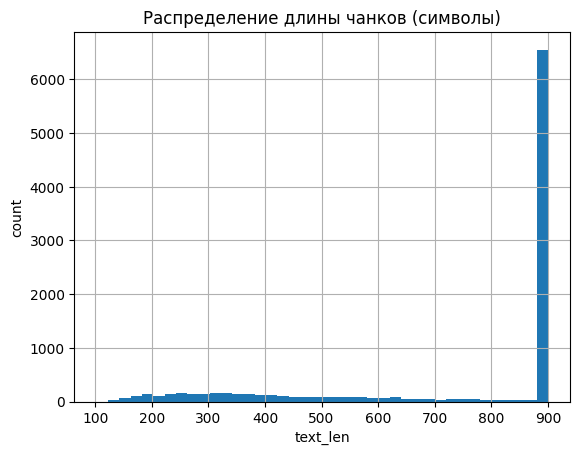

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
meta_df["text_len"].hist(bins=40)
plt.title("Распределение длины чанков (символы)")
plt.xlabel("text_len")
plt.ylabel("count")
plt.show()

### EDA: пример документов и запросов

In [ ]:
print("Пример документа из корпуса:")
row = meta_df.sample(1).iloc[0]
print("doc_id:", row["doc_id"])
print("source:", row["source"])
print("title:", row["title"])
print(row["text"])

print("\nПример пары query → pos_doc_id:")
p = pairs_df.sample(1).iloc[0]
print("pair_source:", p["pair_source"])
print("query:", p["query"])
print("pos_doc_id:", p["pos_doc_id"])

Пример документа из корпуса:
doc_id: codesearchnet::codesn_60::0
source: codesearchnet
title: codesn_60
Comment: Returns the generator reactive power variable set. Code: def _get_qgen_var(self, generators, base_mva): Qg = array([g.q / base_mva for g in generators]) Qmin = array([g.q_min / base_mva for g in generators]) Qmax = array([g.q_max / base_mva for g in generators]) return Variable("Qg", len(generators), Qg, Qmin, Qmax)

Пример пары query → pos_doc_id:
pair_source: docs
query: DStream.html
pos_doc_id: spark_docs::DStream.html::0


## RETRIEVER блок

### Подготовка retriever: загрузка embedding-модели

In [ ]:
import torch
from sentence_transformers import SentenceTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


retriever = SentenceTransformer(EMB_MODEL_NAME, device=device)
print("Retriever model:", EMB_MODEL_NAME)

Device: cuda


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Retriever model: sentence-transformers/all-mpnet-base-v2


### Embedding корпуса, retrieval top-k, Recall@K

In [ ]:
def embed_texts(model: SentenceTransformer, texts: list[str], batch_size: int = 64) -> np.ndarray:
    emb = model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        normalize_embeddings=True
    )
    return np.asarray(emb, dtype=np.float32)

# corpus embeddings (будут пересчитываться после обучения)
corpus_texts = meta_df["text"].tolist()
corpus_ids = meta_df["doc_id"].tolist()

def build_corpus_index(model: SentenceTransformer, batch_size: int = 64):
    emb = embed_texts(model, corpus_texts, batch_size=batch_size)
    return emb  # shape: [N, D]

def retrieve_topk(query: str, model: SentenceTransformer, corpus_emb: np.ndarray, k: int = 10):
    q_emb = model.encode([query], normalize_embeddings=True)
    q_emb = np.asarray(q_emb, dtype=np.float32)  # [1, D]
    sims = (q_emb @ corpus_emb.T).ravel()        # [N]
    top_idx = np.argsort(-sims)[:k]
    results = []
    for idx in top_idx:
        results.append({
            "doc_id": corpus_ids[int(idx)],
            "score": float(sims[int(idx)]),
            "source": meta_df.iloc[int(idx)]["source"],
            "title": meta_df.iloc[int(idx)]["title"],
            "url": meta_df.iloc[int(idx)]["url"],
            "text": meta_df.iloc[int(idx)]["text"],
        })
    return results

def recall_at_k(model, corpus_emb_np: np.ndarray, pairs_df, k: int = 10, batch_size: int = 64):
    device = model.device if hasattr(model, "device") else ("cuda" if torch.cuda.is_available() else "cpu")

    queries = pairs_df["query"].tolist()
    true_ids = pairs_df["pos_doc_id"].tolist()

    # Encode queries
    q_emb = model.encode(queries, batch_size=batch_size, show_progress_bar=True, normalize_embeddings=True)
    q_emb = torch.tensor(q_emb, dtype=torch.float32, device=device)  # [Q, D]

    # Corpus to torch on device
    corpus_emb = torch.tensor(corpus_emb_np, dtype=torch.float32, device=device)  # [N, D]

    hits = 0
    # считаем батчами, чтобы не съесть память на огромном QxN
    for start in range(0, q_emb.shape[0], batch_size):
        qb = q_emb[start:start+batch_size]          # [b, D]
        sims = qb @ corpus_emb.T                    # [b, N]

        topk = torch.topk(sims, k=k, dim=1).indices # [b, k]
        for i in range(topk.shape[0]):
            retrieved_ids = [corpus_ids[int(j)] for j in topk[i].tolist()]
            if true_ids[start+i] in retrieved_ids:
                hits += 1

    return hits / len(queries)

### Train/Val split + замер Recall@K ДО обучения

In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    pairs_df,
    test_size=0.1,
    random_state=SEED,
    stratify=pairs_df["pair_source"]
)

print("Train pairs:", len(train_df))
print("Val pairs:", len(val_df))

# corpus index before training
corpus_emb = build_corpus_index(retriever, batch_size=64)

print("\nRecall@10 BEFORE training:")
r10_before = recall_at_k(retriever, corpus_emb, val_df, k=10, batch_size=64)
print("R@10:", round(r10_before, 4))

Train pairs: 2972
Val pairs: 331


Batches:   0%|          | 0/154 [00:00<?, ?it/s]


Recall@10 BEFORE training:


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

R@10: 0.9366


### Обучение retriever на общем датасете

In [ ]:
from sentence_transformers import InputExample, losses
from torch.utils.data import DataLoader

# Чтобы не ронять память ограничиваем количество train пар по необходимости
max_train_pairs = min(6000, len(train_df))
train_df_small = train_df.sample(max_train_pairs, random_state=SEED)

train_examples = [
    InputExample(texts=[row["query"], meta_df.loc[meta_df["doc_id"] == row["pos_doc_id"], "text"].values[0]])
    for _, row in tqdm(train_df_small.iterrows(), total=len(train_df_small), desc="Building InputExamples")
]

train_loader = DataLoader(
    train_examples,
    shuffle=True,
    batch_size=8,
    drop_last=True,
    num_workers=0,
    pin_memory=False
)

train_loss = losses.MultipleNegativesRankingLoss(retriever)

retriever.fit(
    train_objectives=[(train_loader, train_loss)],
    epochs=1,
    warmup_steps=100,
    show_progress_bar=True,
    use_amp=True
)

print("\nДообучение завершено.")

Building InputExamples: 100%|██████████| 2972/2972 [00:03<00:00, 941.52it/s]


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss



Дообучение завершено.


### Замер Recall@K ПОСЛЕ обучения

In [ ]:
# corpus index after training
corpus_emb = build_corpus_index(retriever, batch_size=64)

print("\nRecall@10 AFTER training:")
r10_after = recall_at_k(retriever, corpus_emb, val_df, k=10, batch_size=64)
print("R@10:", round(r10_after, 4))

VAL_RECALL_AT_10 = r10_after

Batches:   0%|          | 0/154 [00:00<?, ?it/s]


Recall@10 AFTER training:


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

R@10: 0.9879


`R@10: 0.9356` - до обучения
`R@10: 0.9847` - после обучения

> Чему то ретривер значит обучился

## RAG inference (LLM, RAG-pipeline, demonstration)

### LLM генерация: загружаем модель (FLAN-T5)

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained(LLM_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(LLM_NAME).to(device)
model.eval()

def llm_generate(prompt: str, max_new_tokens: int = 220) -> str:
    max_input = getattr(tokenizer, "model_max_length", None)
    if max_input is None or max_input > 4096:
        max_input = 1024
    max_source_tokens = max(128, max_input - max_new_tokens - 16)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=max_source_tokens
    ).to(device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=1
        )
    return tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

### Prompt builder + RAG answer

In [ ]:
def _looks_bad(ans: str) -> bool:
    if ans is None:
        return True
    s = ans.strip()
    if len(s) == 0:
        return True

    if re.fullmatch(r"[\s:|.\-_=]+", s):
        return True
    if re.search(r"(:\s*){8,}", s):
        return True

    return False


def build_prompt_token_budget(question: str, retrieved: list[dict], max_source_tokens: int) -> str:
    head = (
        "Ответь на вопрос, используя ТОЛЬКО информацию из контекста.\n"
        "Если в контексте ответа нет, напиши: NOT_FOUND.\n\n"
        "КОНТЕКСТ:\n"
    )
    tail = f"\n\nВОПРОС: {question}\nОТВЕТ:"

    head_t = len(tokenizer.encode(head, add_special_tokens=False))
    tail_t = len(tokenizer.encode(tail, add_special_tokens=False))
    budget = max(64, max_source_tokens - head_t - tail_t)

    blocks, used = [], 0
    for r in retrieved:
        block = (
            f"- ({r['source']}, {r['doc_id']})\n"
            f"{r['text']}\n"
        )
        t = len(tokenizer.encode(block, add_special_tokens=False))
        if used + t > budget:
            break
        blocks.append(block)
        used += t

    context = "\n---\n".join(blocks)
    return head + context + tail


def retrieval_confidence(retrieved: list[dict]) -> dict:
    if not retrieved:
        return {"top1": 0.0, "gap12": 0.0}
    top1 = float(retrieved[0].get("score", 0.0))
    top2 = float(retrieved[1].get("score", 0.0)) if len(retrieved) > 1 else 0.0
    return {"top1": top1, "gap12": top1 - top2}


def llm_json(prompt: str, max_new_tokens: int = 180) -> dict:
    raw = llm_generate(prompt, max_new_tokens=max_new_tokens)

    m = re.search(r"\{.*\}", raw, flags=re.DOTALL)
    if not m:
        return {"found": False, "confidence": 0.0, "doc_ids": [], "reason": "No JSON"}

    try:
        obj = json.loads(m.group(0))
        obj.setdefault("found", False)
        obj.setdefault("confidence", 0.0)
        obj.setdefault("doc_ids", [])
        obj.setdefault("reason", "")
        return obj
    except Exception:
        return {"found": False, "confidence": 0.0, "doc_ids": [], "reason": "Bad JSON"}


def build_context_from_docs(retrieved: list[dict], doc_ids: list[str], max_docs: int = 2) -> list[dict]:
    chosen = []
    s = set(doc_ids)
    for r in retrieved:
        if r["doc_id"] in s:
            chosen.append(r)
        if len(chosen) >= max_docs:
            break
    if not chosen and retrieved:
        chosen = [retrieved[0]]
    return chosen


def rag_inference(question: str, k: int = 10, show_confidence: bool = True, max_new_tokens: int = 220):
    is_sql = any(x in question.lower() for x in ["sql", "rag_kg", "orders", "refund", "revenue", "customers", "campaign"])
    if is_sql:
        retrieved = [r for r in retrieve_topk(question, retriever, corpus_emb, k=50) if r["source"] == "neon_schema"][:k]
    else:
        retrieved = retrieve_topk(question, retriever, corpus_emb, k=k)

    # ---- 1) LLM self-check (use ONLY top-2 docs to reduce noise) ----
    check_docs = retrieved[:2]

    check_prompt = (
        "You are a strict evaluator.\n"
        "Given CONTEXT and QUESTION, decide if the context contains enough info to answer.\n"
        "Return ONLY a valid JSON object with keys:\n"
        "found (boolean), confidence (number 0..1), doc_ids (list of strings), reason (string).\n"
        "If not enough info, found=false.\n\n"
        "CONTEXT:\n"
    )
    for r in check_docs:
        check_prompt += f"[doc_id={r['doc_id']} | source={r['source']}]\n{r['text']}\n\n"

    check_prompt += f"QUESTION: {question}\nJSON:"

    judge = llm_json(check_prompt, max_new_tokens=160)

    # ---- 2) Build final answer from selected docs (again, keep context small) ----
    chosen_docs = build_context_from_docs(retrieved, judge.get("doc_ids", []), max_docs=2)

    answer_prompt = (
        "Answer the QUESTION using ONLY the CONTEXT.\n"
        "Answer in English.\n"
        "If the answer is not in the context, say in English that the context is insufficient.\n\n"
        "CONTEXT:\n"
    )
    for r in chosen_docs:
        answer_prompt += f"[doc_id={r['doc_id']} | source={r['source']}]\n{r['text']}\n\n"

    answer_prompt += f"QUESTION: {question}\nANSWER (English):"

    answer = llm_generate(answer_prompt, max_new_tokens=max_new_tokens)

    # fallback if model still glitches
    if (not answer) or _looks_bad(answer):
        answer = "В предоставленном контексте нет информации, чтобы уверенно ответить на вопрос."

    # ---- output ----
    print(f"Вопрос: {question}\n")
    print("Найденные RAG наиболее релевантные документы:")
    for r in retrieved:
        print(f"- {r['doc_id']} | source={r['source']} | score={r['score']:.3f}")

    if show_confidence:
        # retriever
        top1 = float(retrieved[0]["score"]) if retrieved else 0.0
        top2 = float(retrieved[1]["score"]) if len(retrieved) > 1 else 0.0
        print(f"\nУверенность retriever (Val Recall@10): {VAL_RECALL_AT_10:.4f}")
        print(f"Уверенность по вопросу (top1, gap12): {top1:.3f}, {(top1-top2):.3f}")

        # LLM self-confidence
        llm_found = bool(judge.get("found", False))
        llm_conf = float(judge.get("confidence", 0.0))
        llm_reason = str(judge.get("reason", ""))
        llm_docs = judge.get("doc_ids", [])
        print(f"Уверенность LLM: found={llm_found}, confidence={llm_conf:.2f}, doc_ids={llm_docs}, reason={llm_reason}")

    print("\nОтвет:")
    print(answer)

    return {
        "question": question,
        "retrieved": retrieved,
        "llm_judge": judge,
        "answer": answer
    }

### Демонстрационные вопросы (docs + code)

In [ ]:
tests = [
    "Explain what Apache Spark is and list its main components (SQL, ML, streaming, graph).",
    "What is Trino and what does 'data federation' mean in this context?",
    "Compare Apache Hive and Trino: when would you use each one?",
    "How do I read a JSON file in Python? Give a short example.",
    "How can I filter rows in a Spark DataFrame? Provide a brief explanation.",
    "What is the difference between batch processing and structured streaming in Spark?",
    "What is Spark SQL and what kinds of workloads is it used for?",
    "What is Hive Metastore and why is it important in a data lake setup?",
    "Give an example of a simple aggregation query in Trino (SQL).",
    "In Python, how do I handle missing keys safely when reading a dict? Provide a short example."
]

for q in tests:
    print("="*110)
    rag_inference(q, k=3, show_confidence=True, max_new_tokens=220)

Вопрос: Explain what Apache Spark is and list its main components (SQL, ML, streaming, graph).

Найденные RAG наиболее релевантные документы:

Уверенность retriever (Val Recall@10): 0.9879
Уверенность по вопросу (top1, gap12): 0.000, 0.000
Уверенность LLM: found=False, confidence=0.00, doc_ids=[], reason=No JSON

Ответ:
What is Spark and what are its main components?
Вопрос: What is Trino and what does 'data federation' mean in this context?

Найденные RAG наиболее релевантные документы:
- trino_docs::use-cases.html::1 | source=trino_docs | score=0.701
- trino_docs::concepts.html::1 | source=trino_docs | score=0.580
- trino_docs::concepts.html::7 | source=trino_docs | score=0.576

Уверенность retriever (Val Recall@10): 0.9879
Уверенность по вопросу (top1, gap12): 0.701, 0.120
Уверенность LLM: found=False, confidence=0.00, doc_ids=[], reason=No JSON

Ответ:
Trino is a tool designed to efficiently query vast amounts of data using distributed queries.
Вопрос: Compare Apache Hive and Trino

In [ ]:
db_tests = [
    "Which tables exist in the rag_kg schema? List them and briefly describe what each table stores.",
    "I need an aggregated report of total revenue by day. Which tables/columns should I use and what SQL would you write?",
    "How do I get monthly revenue by product category? Provide SQL using orders, order_items, and products.",
    "How can I compute conversion from web events to purchases? Which tables are involved and what SQL would you propose?",
    "I want to analyze refunds rate by month (refund amount / total sales). Write SQL for that.",
    "How do I join orders with customers to get revenue by customer segment? Provide SQL.",
    "Which table contains marketing campaign information, and how do I attribute orders to campaigns? Provide SQL.",
    "How do I calculate average order value (AOV) by store_type? Provide SQL.",
    "How to get top 10 products by revenue? Provide SQL.",
    "How to investigate support load: number of support tickets per day and top categories? Provide SQL."
]

print("\n" + "="*110)
print("DB / SQL questions (Neon schema)")
for q in db_tests:
    print("="*110)
    rag_inference(q, k=3, show_confidence=True, max_new_tokens=260)


DB / SQL questions (Neon schema)
Вопрос: Which tables exist in the rag_kg schema? List them and briefly describe what each table stores.

Найденные RAG наиболее релевантные документы:
- neon_schema::rag_kg.products::0 | source=neon_schema | score=0.598
- neon_schema::rag_kg.stores::0 | source=neon_schema | score=0.597
- neon_schema::rag_kg.customers::0 | source=neon_schema | score=0.561

Уверенность retriever (Val Recall@10): 0.9879
Уверенность по вопросу (top1, gap12): 0.598, 0.001
Уверенность LLM: found=False, confidence=0.00, doc_ids=[], reason=No JSON

Ответ:
price (numeric, nullable=NO) — Current list.
Вопрос: I need an aggregated report of total revenue by day. Which tables/columns should I use and what SQL would you write?

Найденные RAG наиболее релевантные документы:
- neon_schema::rag_kg.daily_fx_rates::0 | source=neon_schema | score=0.317

Уверенность retriever (Val Recall@10): 0.9879
Уверенность по вопросу (top1, gap12): 0.317, 0.317
Уверенность LLM: found=False, confidenc

### Сохранение и переиспользование артефактов бейзлайна

In [ ]:
import os
import json
import joblib
import numpy as np
from datetime import datetime

ART_DIR = "artifacts_rag_baseline"
os.makedirs(ART_DIR, exist_ok=True)

run_id = datetime.utcnow().strftime("%Y%m%d_%H%M%S")
RUN_DIR = os.path.join(ART_DIR, f"run_{run_id}")
os.makedirs(RUN_DIR, exist_ok=True)

print("Saving to:", RUN_DIR)

# 1) Save retriever model (SentenceTransformers)
# retriever should be SentenceTransformer instance
retriever_dir = os.path.join(RUN_DIR, "retriever_model")
retriever.save(retriever_dir)
print("✅ Saved retriever to:", retriever_dir)

# 2) Save corpus (list[dict])
# It may be big; joblib compression helps.
corpus_path = os.path.join(RUN_DIR, "corpus.joblib")
joblib.dump(corpus, corpus_path, compress=3)
print("✅ Saved corpus to:", corpus_path, "| items:", len(corpus))

# 3) Save corpus embeddings
emb_path = os.path.join(RUN_DIR, "corpus_emb.npy")
np.save(emb_path, corpus_emb)
print("✅ Saved corpus embeddings to:", emb_path, "| shape:", corpus_emb.shape)

# 4) Save training pairs / split (optional but useful)
try:
    pairs_path = os.path.join(RUN_DIR, "pairs_df.parquet")
    pairs_df.to_parquet(pairs_path, index=False)
    print("✅ Saved pairs_df to:", pairs_path, "| rows:", len(pairs_df))
except Exception as e:
    print("⚠️ Could not save pairs_df:", e)

try:
    train_path = os.path.join(RUN_DIR, "train_df.parquet")
    val_path = os.path.join(RUN_DIR, "val_df.parquet")
    train_df.to_parquet(train_path, index=False)
    val_df.to_parquet(val_path, index=False)
    print("✅ Saved train/val splits.")
except Exception as e:
    print("⚠️ Could not save train/val splits:", e)

# 5) Save config/metadata
meta = {
    "run_id": run_id,
    "created_utc": datetime.utcnow().isoformat() + "Z",
    "llm_name": globals().get("LLM_NAME"),
    "emb_model_name": globals().get("EMB_MODEL_NAME"),
    "chunk_size": globals().get("CHUNK_SIZE"),
    "chunk_overlap": globals().get("CHUNK_OVERLAP"),
    "seed": globals().get("SEED"),
    "val_recall_at_10": globals().get("VAL_RECALL_AT_10"),
    "notes": "Baseline RAG artifacts: retriever + corpus + corpus_emb (+pairs).",
}
meta_path = os.path.join(RUN_DIR, "meta.json")
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)
print("✅ Saved metadata to:", meta_path)

print("\nDONE.")

Saving to: artifacts_rag_baseline/run_20260225_091001


/tmp/ipython-input-935682625.py:10: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  run_id = datetime.utcnow().strftime("%Y%m%d_%H%M%S")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Saved retriever to: artifacts_rag_baseline/run_20260225_091001/retriever_model
✅ Saved corpus to: artifacts_rag_baseline/run_20260225_091001/corpus.joblib | items: 9796
✅ Saved corpus embeddings to: artifacts_rag_baseline/run_20260225_091001/corpus_emb.npy | shape: (9796, 768)
✅ Saved pairs_df to: artifacts_rag_baseline/run_20260225_091001/pairs_df.parquet | rows: 3303
✅ Saved train/val splits.
✅ Saved metadata to: artifacts_rag_baseline/run_20260225_091001/meta.json

DONE.


/tmp/ipython-input-935682625.py:53: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_utc": datetime.utcnow().isoformat() + "Z",


In [ ]:
import shutil
shutil.make_archive("artifacts_rag_baseline_latest", "zip", RUN_DIR)
print("Created zip:", "artifacts_rag_baseline_latest.zip")

Created zip: artifacts_rag_baseline_latest.zip


Как потом загружать эти артефакты:

```python
import os
import json
import joblib
import numpy as np
from sentence_transformers import SentenceTransformer

RUN_DIR = "artifacts_rag_baseline/run_YYYYMMDD_HHMMSS"

# 1) load metadata
with open(os.path.join(RUN_DIR, "meta.json"), "r", encoding="utf-8") as f:
    meta = json.load(f)

print("Loaded meta:", meta)

# 2) load retriever
retriever = SentenceTransformer(os.path.join(RUN_DIR, "retriever_model"))
print("✅ Retriever loaded")

# 3) load corpus
corpus = joblib.load(os.path.join(RUN_DIR, "corpus.joblib"))
print("✅ Corpus loaded:", len(corpus))

# 4) load embeddings
corpus_emb = np.load(os.path.join(RUN_DIR, "corpus_emb.npy"))
print("✅ Corpus embeddings loaded:", corpus_emb.shape)

# 5) (optional) load pairs_df
import pandas as pd
pairs_path = os.path.join(RUN_DIR, "pairs_df.parquet")
if os.path.exists(pairs_path):
    pairs_df = pd.read_parquet(pairs_path)
    print("✅ pairs_df loaded:", len(pairs_df))
else:
    pairs_df = None
    print("pairs_df not found (ok)")

# You can now reuse your existing retrieve_topk() / rag_inference() with retriever+corpus+corpus_emb.
```